<a href="https://colab.research.google.com/github/Zawertia/Movie-Industry-Data-Analysis-1980-2023-/blob/main/DA34_%D0%9F%D1%96%D0%B4%D1%81%D1%83%D0%BC%D0%BA%D0%BE%D0%B2%D0%B8%D0%B9_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82_2_%D0%9F%D0%B8%D1%80%D0%BE%D0%B3%D0%BE%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
base = pd.read_csv('survey_results_public.csv', low_memory=False)
# Довелося додати "low_memory=False", бо видавало помилку
# /tmp/ipykernel_1283/3022453229.py:1: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
# чомусь у інших учасникіів потоку цю помилку не видає (або не у всіх видає)
# створимо функцію для перевірки входження певного рядка в список колонок, виведених в помилці
cols = [56,74,92,97,98,105,109,110,132,162,165]
def is_in_cols(col):
  if col in base.columns[cols]:
    print(f"Колонка {col} є серед вибраних")
  else:
    print(f"Колонки {col} немає серед вибраних")
# нормалізувати певні колонки з цього набору  буду тільки в тому випадку, якщо вони мені знадобляться для аналізу
schema = pd.read_csv('survey_results_schema.csv')

In [ ]:
base.info('all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 172 columns):
 #    Column                                    Dtype  
---   ------                                    -----  
 0    ResponseId                                int64  
 1    MainBranch                                object 
 2    Age                                       object 
 3    EdLevel                                   object 
 4    Employment                                object 
 5    EmploymentAddl                            object 
 6    WorkExp                                   float64
 7    LearnCodeChoose                           object 
 8    LearnCode                                 object 
 9    LearnCodeAI                               object 
 10   AILearnHow                                object 
 11   YearsCode                                 float64
 12   DevType                                   object 
 13   OrgSize                                   ob

In [ ]:
schema.info('all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   qid       139 non-null    object 
 1   qname     139 non-null    object 
 2   question  139 non-null    object 
 3   type      139 non-null    object 
 4   sub       49 non-null     object 
 5   sq_id     49 non-null     float64
dtypes: float64(1), object(5)
memory usage: 6.6+ KB


In [ ]:
base.shape

(49191, 172)

In [ ]:
pd.set_option('display.max_columns', None)
base.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DatabaseChoice,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,DatabaseHaveEntry,DatabaseWantEntry,PlatformChoice,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,PlatformHaveEntry,PlatformWantEntry,WebframeChoice,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,WebframeHaveEntry,WebframeWantEntry,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,DevEnvHaveEntry,DevEnvWantEntry,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,SOTagsHaveEntry,SOTagsWant Entry,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackHaveEntry,OfficeStackWantEntry,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,CommPlatformHaveEntr,CommPlatformWantEntr,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,NaN,I'm not sure,I have neither consider or transitioned into a...,7.0,3.0,Ukraine,EUR European Euro,52800.0,Yes,Bash/Shell (all shells);Dart;SQL,Dart,Dart,NaN,NaN,Yes,Cloud Firestore;PostgreSQL,NaN,NaN,NaN,NaN,Yes,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,Yes,Android Studio;Notepad++;Visual Studio;Visual ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Windows;MacOS;Android,Windows;MacOS;Android;iOS;iPadOS,Confluence;GitHub;GitLab;Jira;Markdo

In [ ]:
schema

,qid,qname,question,type,sub,sq_id
0,QID18,TechEndorse_1,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
1,QID18,TechEndorse_2,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
2,QID18,TechEndorse_3,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
3,QID18,TechEndorse_4,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
4,QID18,TechEndorse_5,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0
...,...,...,...,...,...,...
134,QID103,AIAgentObsWrite,Was the tool or tools for AI agent observabili...,TE,NaN,NaN
135,QID92,AIAgentExternal,You indicated you use or develop AI agents as ...,MC,NaN,NaN
136,QID104,AIAgentExtWrite,"Was the out-of-the-box agents, copilots or ass...",TE,NaN,NaN
137,QID100,AIHuman,"In the future, if AI can do most coding tasks,...",MC,NaN,NaN


 ## Завдання 1. Підрахунок загальної кількості респондентів
Визначити загальну кількість респондентів, які взяли участь в опитуванні Stack Overflow. Це базова метрика, яка дасть уявлення про обсяг датасету.

In [ ]:
# спочатку перевіряємо чи є колонка ResponseId серед списку тих, які мають змішані типи даних
is_in_cols('ResponseId')

# тепер рахуємо кількість унікальних респондентів
# .nunique() - метод Series, який підраховує кількість унікальних значень у стовпці
respondents_amount = base['ResponseId'].nunique()
print('\nЗагальна кількість унікальних респондентів:', respondents_amount)

Колонки ResponseId немає серед вибраних

Загальна кількість унікальних респондентів: 49191


## Завдання 2. Аналіз повноти відповідей респондентів

**Опис завдання:** Визнач, скільки респондентів відповіли на всі запитання опитування. Для цього тобі знадобиться:

- Отримати список питань з файлу survey_results_schema (поле "qname")
- Перевірити наявність відповідей на ці питання у кожного респондента
- Підрахувати кількість респондентів без пропущених значень

**Фінальний результат:** Число, що показує кількість респондентів, які відповіли на всі запитання з опитування.

In [ ]:
# questions - створюємо множину назв питань, які присутні одночасно в qname та серед стовпців base
# використання set() та qname.unique() створює множину унікальних qname
schema_questions= set(schema['qname'].unique())
print('Множина запитань з таблиці зі схемою опитування:', schema_questions)

base_questions = set (base.columns)
print ('\nМножина запитань з таблиці результатів опитування:', base_questions)
# після чого ми беремо перетин із base.columns, щоб отримати лише ті питання, які існують у датафреймі
joint_questions=base_questions.intersection(schema_questions)
print ('\nМножина запитань, які містятья в обох таблицях:',joint_questions)
# dropna(): видаляє рядки, де є пропуски у зазначених стопвцях
all_answers = base.dropna(subset = list(joint_questions))
print ('\nСписок респондентів, які відповіли на всі запитання опитування:\n', all_answers)
# shape[0] повертає кількість рядків - тобто кількість респондентів, які відповіли на всі запитання
all_answers.shape
print ('=' * 57)
print(f'\nКількість респондентів, які відповіли на всі запитання опитування:', all_answers['ResponseId'].count())

Множина запитань з таблиці зі схемою опитування: {'TechEndorse_4', 'AIModelsChoice', 'TechOppose_1', 'DatabaseWantEntry', 'WorkExp', 'CommPlatformWantEntr', 'AIComplex', 'SO_Actions_10', 'TechEndorse_9', 'SO_Dev_Content', 'AIAgentKnowWrite', 'LanguageChoice', 'AIAgentExtWrite', 'TechOppose_13', 'TechOppose_5', 'AITool', 'JobSatPoints_10', 'SOFriction', 'AIHuman', 'OfficeStackWantEntry', 'OfficeStackHaveEntry', 'TechEndorse_8', 'SO_Actions_3', 'AIAgent_Uses', 'PlatformChoice', 'AIFrustration', 'SO_Actions_15', 'SOComm', 'TechOppose_11', 'PlatformHaveEntry', 'LanguagesHaveEntry', 'JobSatPoints_8', 'Industry', 'AIModels', 'AIAgentChange', 'SO_Actions_6', 'ToolCountWork', 'AIAgentOrchWrite', 'DevType', 'SO_Actions_4', 'JobSatPoints_13', 'SO_Actions_1', 'Database', 'TechEndorse_3', 'AIAgentObsWrite', 'EdLevel', 'JobSatPoints_11', 'JobSat', 'SOAccount', 'TechEndorse_13_TEXT', 'SO_Actions_16', 'TechOppose_2', 'JobSatPoints_2', 'SOTags', 'AIThreat', 'JobSatPoints_5', 'JobSatPoints_6', 'AIOpen'

## Завдання 3. Статистичний аналіз досвіду респондентів



**Опис завдання:** Обчисли міри центральної тенденції для поля WorkExp (досвід роботи респондентів). Тобі потрібно знайти:

- Середнє значення (mean)
- Медіану (median)
- Моду (mode)

**Фінальний результат:** Таблиця або серія значень з трьома показниками: середнє, медіана та мода для досвіду роботи респондентів.


In [ ]:
# спочатку перевіряємо чи є колонка WorkExp серед списку тих, які мають змішані типи даних
is_in_cols('WorkExp')

# Тепер повертаємо міри центральної тенденції
print('\nМіри центральної тенденції:')
print(f'Середній стаж роботи респондентів: {round(base['WorkExp'].mean(), 1)}')
print(f'Медіана робочого стажу респондентів: {round(base['WorkExp'].median(), 1)}')
print(f'Мода робочого стажу респондентів: {base['WorkExp'].mode()[0]}')

Колонки WorkExp немає серед вибраних

Міри центральної тенденції:
Середній стаж роботи респондентів: 13.4
Медіана робочого стажу респондентів: 10.0
Мода робочого стажу респондентів: 10.0


## Завдання 4. Аналіз віддаленої роботи


**Опис завдання:** Визнач кількість респондентів, які працюють віддалено (remote). Тобі потрібно знайти відповідне поле в датасеті та підрахувати кількість працівників, які обрали цей формат роботи.

**Фінальний результат:** Число, що показує кількість респондентів, які працюють віддалено.

In [ ]:
# спочатку перевіряємо чи є колонка RemoteWork серед списку тих, які мають змішані типи даних
is_in_cols('RemoteWork')

# підраховуємо кількість рядків у base, де значення у відповідній колонці == 'Remote'
remote_count = (base['RemoteWork'] == 'Remote').sum()
print ('\nКількість респонднтів, які працюють віддалено:', remote_count)

Колонки RemoteWork немає серед вибраних

Кількість респонднтів, які працюють віддалено: 10931


## Завдання 5. Визначення популярності Python


**Опис завдання:** Обчисли відсоток респондентів, які програмують на Python. Зверни увагу, що поле з мовами програмування може містити множинні значення, тому потрібно перевірити наявність Python в цьому полі.

**Фінальний результат:** Відсоток респондентів, які програмують на Python (наприклад, 45.3%).

Формат здачі: Комірка з кодом та виведеним відсотковим значенням.

In [ ]:
# спочатку перевіряємо чи є колонка LanguageHaveWorkedWith серед списку тих, які мають змішані типи даних
is_in_cols('LanguageHaveWorkedWith')

# Створюємо новий стовпець worked_with_python, який містить True/False
#  True - респондент вказував Пайтон у колонці LanguageHaveWorkedWith
base['worked_with_python'] = base['LanguageHaveWorkedWith'].str.contains('Python', case=False).fillna(False)
# str.contains('...') - шукаємо слово 'python' без урахування регістру
# .fillna(False) замінюємо пропуски NaN на False
#print (base['worked_with_python'])

worked_with_python = (base['worked_with_python']==True).sum() # sum() - рахуємо загальну кількість респондентів, які працювали з Python
print (f'\nКількість респондентів, які вказали знання мови Python: {worked_with_python}')

# - обчислюємо частку таких респондентів у відсотках
pcnt_worked_with_python = round((worked_with_python/base['worked_with_python'].count()*100),1)
print(f'Відсоток таких респондентів: {pcnt_worked_with_python}%\n')

Колонки LanguageHaveWorkedWith немає серед вибраних

Кількість респондентів, які вказали знання мови Python: 18466
Відсоток таких респондентів: 37.5%



/tmp/ipykernel_366/2247855921.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base['worked_with_python'] = base['LanguageHaveWorkedWith'].str.contains('Python', case=False).fillna(False)


## Завдання 6. Аналіз шляхів навчання програмуванню


**Опис завдання:** Визнач, скільки респондентів навчалося програмувати за допомогою онлайн курсів. Знайди відповідне поле в датасеті, яке описує способи навчання, та підрахуй тих, хто обрав онлайн курси.

**Фінальний результат:** Число, що показує кількість респондентів, які навчалися програмувати через онлайн курси.

In [ ]:
# спочатку перевіряємо чи є колонка LearnCode серед списку тих, які мають змішані типи даних
is_in_cols('LearnCode')

# Створюємо новий стовпець Learned_with_online_courses (True/False)
# True - респондент навчався на онлайн курсах (дані по ствпцю LearnCode)
base['Learned_with_online_courses'] = base['LearnCode'].str.contains('online courses', case=False).fillna(False)
#print(base['Learned_with_online_courses'])

# Підраховуємо кількість респондентів, які навчались на онлайн-курсах
total_online_courses_learners = (base['Learned_with_online_courses']==True).sum()
print(f'\nКількість респондентів, які навчались на онлайн-курсах: {total_online_courses_learners}\n')

Колонки LearnCode немає серед вибраних

Кількість респондентів, які навчались на онлайн-курсах: 10973



/tmp/ipykernel_366/3926340936.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base['Learned_with_online_courses'] = base['LearnCode'].str.contains('online courses', case=False).fillna(False)


## Завдання 7. Географічний аналіз компенсації Python-розробників



**Опис завдання:** Серед респондентів, що програмують на Python, проведи аналіз компенсації (ConvertedCompYearly) в розрізі країн. Для кожної країни обчисли:

- Середню суму компенсації
- Медіанну суму компенсації

**Фінальний результат:** DataFrame з колонками: країна, середня компенсація, медіанна компенсація.

In [ ]:
# спочатку перевіряємо чи є колонка ConvertedCompYearly та Country серед списку тих, які мають змішані типи даних
is_in_cols('ConvertedCompYearly')
is_in_cols('Country')

# python_experienced - створюємо таблицю лише з тими, хто працював з Пайтоном
python_experienced = base[base['worked_with_python']==True]

# Видаляємо рядки, де відсутнє значення запрлати (ConvertedCompYearly)
python_experienced = python_experienced[python_experienced['ConvertedCompYearly'].notna()]

# .groupby() - групуємо дані за країною (Country) і обчислюємо середню та медіанну зарплату для кожної країни
py_progers_by_country = python_experienced.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median']).round(0).astype(int).reset_index()
py_progers_by_country # py_progers_by_country - таблиця з результатами

Колонки ConvertedCompYearly немає серед вибраних
Колонки Country немає серед вибраних


,Country,mean,median
0,Afghanistan,22329,1000
1,Albania,47218,50000
2,Algeria,20187,7088
3,Andorra,226104,226104
4,Antigua and Barbuda,1,1
...,...,...,...
148,"Venezuela, Bolivarian Republic of...",9909,3000
149,Viet Nam,218837,8254
150,Yemen,32930,23672
151,Zambia,5424,3206


## Завдання 8. Аналіз освіти найбільш оплачуваних спеціалістів


**Опис завдання:** Визнач рівні освіти 5 респондентів з найбільшою компенсацією. Тобі потрібно:

- Відсортувати респондентів за рівнем компенсації
- Вибрати топ-5
- Показати їх рівні освіти

**Фінальний результат:** Список або таблиця з 5 рівнями освіти найбільш оплачуваних респондентів.

In [ ]:
# спочатку перевіряємо чи є колонка EdLevel серед списку тих, які мають змішані типи даних
# інші колонки вже перевіряли раніше
is_in_cols('EdLevel')

# Вибираємо 3 стовпці: ResponseID, EdLevel, ConvertedCompYearly
top_salary = base[['ResponseId','EdLevel','ConvertedCompYearly']]

# Сортуємо за колонкою ConvertedCompYearly у порядку спадання (від більшої зарплати до меншої)
top_salary = top_salary.sort_values('ConvertedCompYearly', ascending=False)

# reset_index (drop = True) - обновлюємо індекси після сортування, старий індекс видаляємо
top_salary = top_salary.reset_index(drop = True)

# head (5) - ТОП-5 респондентів з найвищою зарплатою
top_salary.head(5)

Колонки EdLevel немає серед вибраних


,ResponseId,EdLevel,ConvertedCompYearly
0,34268,"Associate degree (A.A., A.S., etc.)",50000000.0
1,28701,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",33552715.0
2,43144,"Associate degree (A.A., A.S., etc.)",18387548.0
3,35354,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",15430267.0
4,45972,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",13921760.0


## *Завдання 9. Аналіз популярності Python по віковим категоріям


* *(виконання необов'язкове, за бажанням)*

**Опис завдання:** Для кожної вікової категорії визнач відсоток респондентів, які програмують на Python. Це дасть уявлення про те, в яких вікових групах Python є найпопулярнішим.

**Фінальний результат:** Таблиця з колонками: вікова категорія, відсоток Python-розробників.

In [ ]:
# у нас уже є стовпець worked_with_python, який містить True/False
# створюємо таблицю для подальших розрахунків
# обриаємо лише тих респондентів, які мали досвід роботи з Пайтоном
python_base = base[base ['worked_with_python']==True]

# Обираємо лише ті рядки, в яких заповнені значення
python_base = python_base [python_base['Age'].notna()]

# Відбираємо до таблиці лише ті колонки, які нас цікавлять
python_base = python_base [['Age','worked_with_python']]

# Групуємо дані по віковій категорії (Age) та підраховуємо кількість рядків в кожній з них.
python_by_age_cat = python_base.groupby('Age')['worked_with_python'].count().reset_index()

# Додаємо колонку з розрахунком відсоткового значення Python-розробників у кожній групі
python_by_age_cat ['percent_by_age_cat'] = ((python_by_age_cat['worked_with_python']/python_by_age_cat['worked_with_python'].sum())*100).round(2)

# Відсортуємо значення по спаданню
sorted_python_by_age_cat= python_by_age_cat.sort_values('worked_with_python', ascending = False)
print(sorted_python_by_age_cat)

                 Age  worked_with_python  percent_by_age_cat
1    25-34 years old                6102               33.04
2    35-44 years old                4862               26.33
0    18-24 years old                3684               19.95
3    45-54 years old                2424               13.13
4    55-64 years old                 978                5.30
5  65 years or older                 298                1.61
6  Prefer not to say                 118                0.64


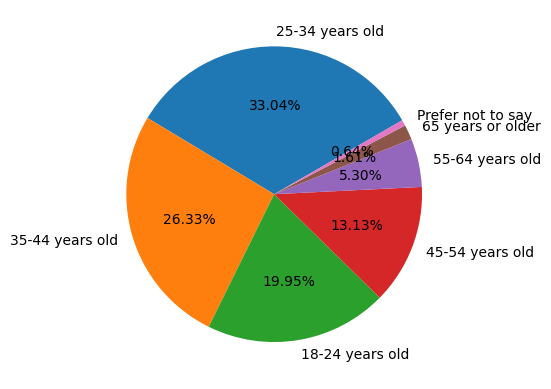

In [ ]:
# Побудуємо візуалізацію останньої таблиці
plt.pie(sorted_python_by_age_cat['worked_with_python'], labels=sorted_python_by_age_cat['Age'], autopct='%1.2f%%', startangle=30)
plt.show()

## *Завдання 10. Аналіз індустрій серед високооплачуваних віддалених працівників


*(виконання необов'язкове, за бажанням)

Інструмент, який потрібен для виконання цього завдання: Pandas (перцентилі, множинна фільтрація, підрахунок частоти)

**Опис завдання:** Знайди респондентів, які:

- Знаходяться у 75 перцентилі за компенсацією (тобто заробляють більше, ніж 75% респондентів)
- Працюють віддалено
- Для цієї групи визнач найрозповсюдженіші індустрії.

**Фінальний результат:** Список або таблиця найрозповсюдженіших індустрій серед високооплачуваних віддалених працівників, відсортованих за популярністю.

In [ ]:
# готуємо таблицю для проведення аналізу
# обираємо лише потрібні колонки
base_top_compensation = base[['ConvertedCompYearly','RemoteWork','Industry']]

# Видаляємо рядки, якщо пусте значення хоча б у одній із вказаних колонках
base_top_compensation = base_top_compensation.dropna(subset=['ConvertedCompYearly','RemoteWork','Industry'], how = 'any')

# Визначаємо перцентиль 75%
q75 = base_top_compensation ['ConvertedCompYearly'].quantile(0.75)

# Фільтруємо таблицю, де мають одночасно виконуватись 2 умови:
# Респонденти заробляють більше, ніж 75% респондентів
# Респонденти працюють віддалено
base_top_compensation = base_top_compensation[(base_top_compensation['ConvertedCompYearly'] > q75) & (base_top_compensation['RemoteWork']=='Remote')]

top_industries = base_top_compensation.groupby('Industry').size().sort_values(ascending=False).reset_index(name='Respondents_amount')
top_industries


,Industry,Respondents_amount
0,Software Development,1174
1,Fintech,188
2,Healthcare,186
3,Other:,176
4,"Internet, Telecomm or Information Services",137
5,Banking/Financial Services,87
6,Government,78
7,Media & Advertising Services,75
8,Retail and Consumer Services,65
9,"Transportation, or Supply Chain",63


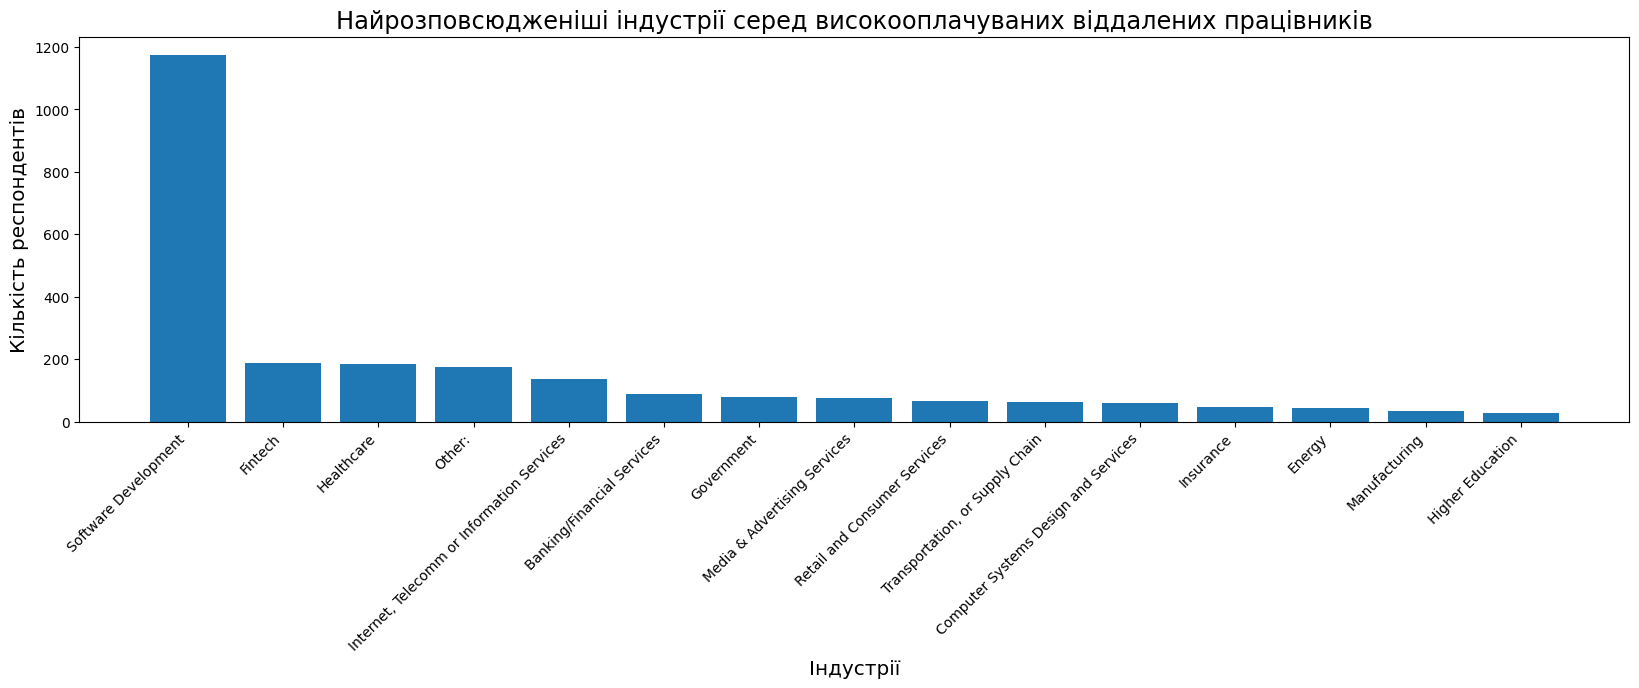

In [ ]:
# Будуємо візуалізацію для таблички вище

plt.figure(figsize=(20,5))
plt.bar(top_industries['Industry'], top_industries['Respondents_amount'])
plt.title('Найрозповсюдженіші індустрії серед високооплачуваних віддалених працівників', fontsize = 'xx-large')
plt.xlabel('Індустрії', fontsize = 'x-large')
plt.ylabel('Кількість респондентів', fontsize = 'x-large')
plt.xticks(rotation=45, ha='right')
plt.show()
